In [1]:
import pandas as pd
import numpy as np

## Read in the data

In [2]:
mdf = pd.read_csv('../data/lmf_parsed.csv', encoding='latin1')
mdf.head()

,SEQN,ELIGSTAT,MORTSTAT,UCOD_LEADING,DIABETES,HYPERTEN,PERMTH_INT,PERMTH_EXM
0,1,2,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,1.0,6.0,0.0,0.0,177.0,177.0
2,3,2,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,0.0,NaN,NaN,NaN,244.0,244.0


In [3]:
gdf = pd.read_sas("../data/DEMO.xpt", format="xport")
gdf.head()

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,WTIREP43,WTIREP44,WTIREP45,WTIREP46,WTIREP47,WTIREP48,WTIREP49,WTIREP50,WTIREP51,WTIREP52
0,1.0,1.0,2.0,2.0,2.0,2.0,29.0,31.0,4.0,2.0,...,10094.017100,9912.461855,9727.078709,10041.524113,9.953956e+03,9857.381983,9865.152486,10327.992682,9809.165049,10323.315747
1,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,27186.728682,27324.345051,28099.663528,27757.066921,2.804929e+04,26716.602006,26877.704909,27268.025234,27406.383620,26984.812909
2,3.0,1.0,2.0,1.0,2.0,10.0,125.0,126.0,3.0,1.0,...,43993.193099,44075.386428,46642.563799,44967.681579,4.457248e+04,44087.945688,44831.370881,44480.987235,45389.112766,43781.905637
3,4.0,1.0,2.0,2.0,1.0,1.0,22.0,23.0,4.0,2.0,...,10702.307249,10531.444441,10346.119327,10636.063039,5.397605e-79,10533.108939,10654.749584,10851.024385,10564.981435,11012.529729
4,5.0,1.0,2.0,2.0,1.0,49.0,597.0,597.0,3.0,1.0,...,93164.782430,92119.608772,95388.490406,94131.383538,9.529781e+04,91325.082461,91640.586117,92817.926915,94282.855382,91993.251203


In [4]:
df = gdf.merge(mdf, on="SEQN", how="inner")
df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,WTIREP50,WTIREP51,WTIREP52,ELIGSTAT,MORTSTAT,UCOD_LEADING,DIABETES,HYPERTEN,PERMTH_INT,PERMTH_EXM
0,1.0,1.0,2.0,2.0,2.0,2.0,29.0,31.0,4.0,2.0,...,10327.992682,9809.165049,10323.315747,2,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,27268.025234,27406.383620,26984.812909,1,1.0,6.0,0.0,0.0,177.0,177.0
2,3.0,1.0,2.0,1.0,2.0,10.0,125.0,126.0,3.0,1.0,...,44480.987235,45389.112766,43781.905637,2,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,1.0,2.0,2.0,1.0,1.0,22.0,23.0,4.0,2.0,...,10851.024385,10564.981435,11012.529729,2,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,1.0,2.0,2.0,1.0,49.0,597.0,597.0,3.0,1.0,...,92817.926915,94282.855382,91993.251203,1,0.0,NaN,NaN,NaN,244.0,244.0


In [5]:
df = df[["ELIGSTAT", "MORTSTAT", "PERMTH_INT", "RIDAGEEX", "DMDEDUC2", "DMDMARTL", "DMDHHSIZ", "INDHHINC"]].dropna()
df = df.query("DMDEDUC2 < 7 and DMDMARTL < 77 and INDHHINC < 13")
df = df[df['ELIGSTAT'] == 1].copy()
df

,ELIGSTAT,MORTSTAT,PERMTH_INT,RIDAGEEX,DMDEDUC2,DMDMARTL,DMDHHSIZ,INDHHINC
4,1,0.0,244.0,597.0,5.0,1.0,3.0,11.0
11,1,0.0,236.0,454.0,4.0,5.0,4.0,11.0
12,1,1.0,16.0,850.0,1.0,1.0,2.0,3.0
13,1,1.0,137.0,974.0,2.0,3.0,1.0,5.0
14,1,0.0,231.0,460.0,5.0,3.0,2.0,8.0
...,...,...,...,...,...,...,...,...
9953,1,0.0,245.0,442.0,4.0,1.0,5.0,8.0
9954,1,0.0,242.0,450.0,3.0,1.0,4.0,7.0
9955,1,0.0,238.0,559.0,3.0,3.0,4.0,9.0
9957,1,0.0,234.0,528.0,1.0,1.0,6.0,4.0


## kNN regressor code

### Normalizing

In [6]:
from sklearn.preprocessing import MinMaxScaler

y = df['PERMTH_INT']
ctrl_list = ['RIDAGEEX']
X = df.loc[:, ctrl_list]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

### Train test split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=100
)

In [8]:
from sklearn.neighbors import KNeighborsRegressor

k = 89
knn_reg = KNeighborsRegressor(n_neighbors=k)
knn_reg.fit(X_train, y_train)

y_pred = knn_reg.predict(X_test)

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(2048)

print("MSE:", mse)
print("R²:", r2)
print("RMSE:", rmse)

MSE: 2048.0543262709984
R²: 0.44200464548099927
RMSE: 45.254833995939045


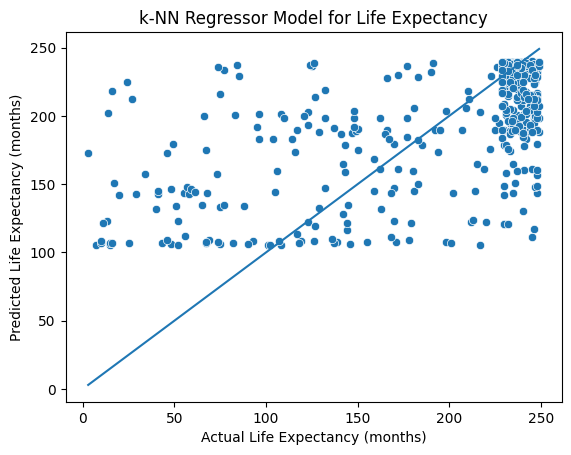

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Life Expectancy (months)")
plt.ylabel("Predicted Life Expectancy (months)")
plt.title("k-NN Regressor Model for Life Expectancy")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
)
plt.show()

### Choosing optimal k

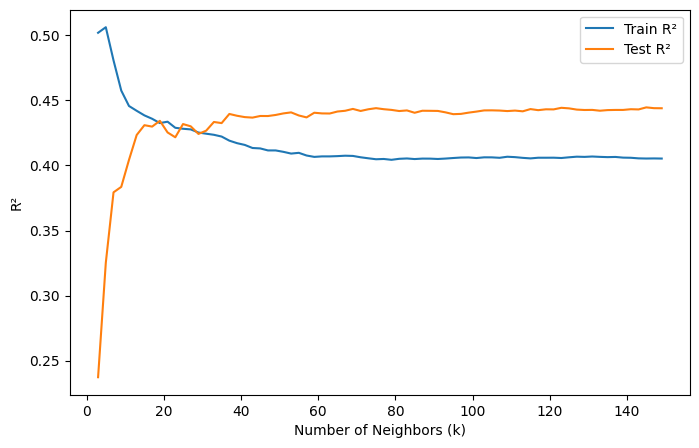

Optimal k (max test R²): 145


In [11]:
k_grid = np.arange(3, 151, 2)

train_r2 = []
test_r2 = []

for k in k_grid:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    
    train_r2.append(r2_score(y_train, y_train_pred))
    test_r2.append(r2_score(y_test, y_test_pred))

plt.figure(figsize=(8,5))
plt.plot(k_grid, train_r2, label="Train R²")
plt.plot(k_grid, test_r2, label="Test R²")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("R²")
plt.legend()
plt.show()

k_optimal = k_grid[np.argmax(test_r2)]
print("Optimal k (max test R²):", k_optimal)